In [30]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [31]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [32]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [33]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2540


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""24/12/2025""","""1258""","""16 13 31 08 24 33""","""01""","""45 11 22""","""Promoción Sí o Sí""","""081316243133""","[8, 13, … 33]",8,13,16,24,31,33,"""08""","""13""","""16""","""24""","""31""","""33""",null,null,null,null,null,null,false,0,"""05_03_08_07_02""",15,"""2""","""3""","""3""","""5""","""3""","""8""","""7""","""2""","""25""","""0""","""5""","""0"""
"""21/12/2025""","""1257""","""25 27 23 36 14 10""","""38""","""03""","""Promoción Sí o Sí""","""101423252736""","[10, 14, … 36]",10,14,23,25,27,36,"""10""","""14""","""23""","""25""","""27""","""36""","""08""","""13""","""16""","""24""","""31""","""33""",true,8,"""04_09_02_02_09""",-19,"""1""","""3""","""3""","""4""","""9""","""2""","""2""","""9""","""26""","""0""","""3""","""0"""
"""17/12/2025""","""1256""","""14 25 10 13 12 39""","""49""","""37 09 29""","""Promoción Sí o Sí""","""101213142539""","[10, 12, … 39]",10,12,13,14,25,39,"""10""","""12""","""13""","""14""","""25""","""39""","""10""","""14""","""23""","""25""","""27""","""36""",true,8,"""02_01_01_11_14""",-26,"""1""","""3""","""3""","""2""","""1""","""1""","""11""","""14""","""29""","""2""","""4""","""0"""
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""10/12/2025""","""1254""","""36 21 07 38 47 48""","""03""","""23 01 50""","""Promoción Sí o Sí""","""072136384748""","[7, 21, … 48]",7,21,36,38,47,48,"""07""","""21""","""36""","""38""","""47""","""48""","""14""","""19""","""27""","""35""","""37""","""50""",false,0,"""14_15_02_09_01""",-69,"""2""","""3""","""3""","""14""","""15""","""2""","""9""","""1""","""41""","""2""","""5""","""0"""
"""07/12/2025""","""1253""","""45 46 32 28 11 43""","""35""","""10 02""","""Promoción Sí o Sí""","""112832434546""","[11, 28, … 46]",11,28,32,43,45,46,"""11""","""28""","""32""","""43""","""45""","""46""","""07""","""21""","""36""","""38""","""47""","""48""",false,0,"""17_04_11_02_01""",60,"""2""","""3""","""3""","""17""","""4""","""11""","""2""","""1""","""35""","""2""","""5""","""0"""
"""03/12/2025""","""1252""","""29 25 28 43 12 33""","""27""","""31 26 34 37""","""Promoción Sí o Sí""","""122528293343""","[12, 25, … 43]",12,25,28,29,33,43,"""12""","""25""","""28""","""29""","""33""","""43""","""11""","""28""","""32""","""43""","""45""","""46""",false,0,"""13_03_01_04_10""",1,"""2""","""2""","""4""","""13""","""3""","""1""","""4""","""10""","""31""","""2""","""5""","""0"""
"""30/11/2025""","""1251""","""38 01 32 37 34 50""","""25""","""45 31 09 08 10""","""Promoción Sí o Sí""","""013234373850""","[1, 32, … 50]",1,32,34,37,38,50,"""01""","""32""","""34""","""37""","""38""","""50""","""12""","""25""","""28""","""29""","""33""","""43""",false,0,"""31_02_03_01_12""",49,"""1""","""4""","""2""","""31""","""2""","""3""","""1""","""12""","""49""","""2""","""5""","""0"""
"""26/11/2025""","""1250""","""14 11 23 07 39 37""","""33""","""17 21""","""Promoción Sí o Sí""","""071114233739""","[7, 11, … 39]",7,11,14,23,37,39,"""07""","""11""","""14""","""23""","""37""","""39""","""01""","""32""","""34""","""37""","""38""","""50""",true,1,"""04_03_09_14_02""",-8,"""4""","""1""","""5""","""4""","""3""","""9""","""14""","""2""","""32""","""1""","""5""","""0"""


In [34]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""07/12/2025""","""1253""","""45 46 32 28 11 43""","""35""","""10 02""","""Promoción Sí o Sí""","""112832434546""","[11, 28, … 46]",11,28,32,43,45,46,"""11""","""28""","""32""","""43""","""45""","""46""","""07""","""21""","""36""","""38""","""47""","""48""",false,0,"""17_04_11_02_01""",60,"""2""","""3""","""3""","""17""","""4""","""11""","""2""","""1""","""35""","""2""","""5""","""0"""
"""03/12/2025""","""1252""","""29 25 28 43 12 33""","""27""","""31 26 34 37""","""Promoción Sí o Sí""","""122528293343""","[12, 25, … 43]",12,25,28,29,33,43,"""12""","""25""","""28""","""29""","""33""","""43""","""11""","""28""","""32""","""43""","""45""","""46""",false,0,"""13_03_01_04_10""",1,"""2""","""2""","""4""","""13""","""3""","""1""","""4""","""10""","""31""","""2""","""5""","""0"""
"""09/11/2025""","""1245""","""18 43 29 32 21 17""","""13""","""04""","""Promoción Sí o Sí""","""171821293243""","[17, 18, … 43]",17,18,21,29,32,43,"""17""","""18""","""21""","""29""","""32""","""43""","""02""","""04""","""06""","""17""","""22""","""31""",false,0,"""01_03_08_03_11""",36,"""3""","""2""","""4""","""1""","""3""","""8""","""3""","""11""","""26""","""1""","""4""","""0"""
"""05/11/2025""","""1244""","""29 28 44 38 14 34""","""19""","""43 15 10 41""","""Promoción Sí o Sí""","""142829343844""","[14, 28, … 44]",14,28,29,34,38,44,"""14""","""28""","""29""","""34""","""38""","""44""","""17""","""18""","""21""","""29""","""32""","""43""",false,0,"""14_01_05_04_06""",30,"""1""","""5""","""1""","""14""","""1""","""5""","""4""","""6""","""30""","""1""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [59]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 200)
jdiff_count = count_column(dfRows, 'jdiff', 200)

j1_count = count_column(dfRows, 'j1', 200)
j2_count = count_column(dfRows, 'j2', 200)
j3_count = count_column(dfRows, 'j3', 200)
j4_count = count_column(dfRows, 'j4', 200)
j5_count = count_column(dfRows, 'j5', 200)

joor_count = count_column(dfRows, "joor", 200)
primes_count = count_column(dfRows, 'primes_count', 200)
evens_count = count_column(dfRows, 'evens_count', 200)
odds_count = count_column(dfRows, 'odds_count', 200)

jsums = count_column(dfRows, 'jsum', 200)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [60]:
dfRows.item(0, 'b2')

13

In [61]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [62]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='08'
df_viz FOR str_b1 = 08


post_str_b1,count,percent
str,u32,f64
"""02""",20,15.037594
"""01""",17,12.781955
"""04""",15,11.278195
"""03""",14,10.526316
"""05""",11,8.270677
…,…,…
"""17""",2,1.503759
"""14""",1,0.75188
"""16""",1,0.75188


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 08
Last 3 results last_results=['10', '03', '13']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""29/10/2025""","""1242""","""33 08 27 14 44 13""","""02""","""39 06 28 48""","""Promoción Sí o Sí""","""081314273344""","[8, 13, … 44]",8,13,14,27,33,44,"""08""","""13""","""14""","""27""","""33""","""44""","""03""","""14""","""20""","""25""","""32""","""35""",false,0,"""05_01_13_06_11""",66,"""1""","""3""","""3""","""5""","""1""","""13""","""6""","""11""","""36""","""2""","""5""","""0"""
"""08/10/2025""","""1236""","""08 29 25 39 23 40""","""20""","""10 41 49 09 18""","""Promoción Sí o Sí""","""082325293940""","[8, 23, … 40]",8,23,25,29,39,40,"""08""","""23""","""25""","""29""","""39""","""40""","""10""","""21""","""24""","""38""","""42""","""47""",true,16,"""15_02_04_10_01""",-8,"""2""","""2""","""4""","""15""","""2""","""4""","""10""","""1""","""32""","""2""","""5""","""0"""
"""24/08/2025""","""1223""","""12 37 16 08 22 17""","""07""","""32 27""","""Promoción Sí o Sí""","""081216172237""","[8, 12, … 37]",8,12,16,17,22,37,"""08""","""12""","""16""","""17""","""22""","""37""","""13""","""19""","""30""","""36""","""40""","""46""",true,8,"""04_04_01_05_15""",-11,"""2""","""4""","""2""","""4""","""4""","""1""","""5""","""15""","""29""","""1""","""4""","""0"""
"""25/06/2025""","""1206""","""38 30 08 27 48 14""","""17""","""18""","""Promoción Sí o Sí""","""081427303848""","[8, 14, … 48]",8,14,27,30,38,48,"""08""","""14""","""27""","""30""","""38""","""48""","""22""","""23""","""24""","""32""","""37""","""47""",false,0,"""06_13_03_08_10""",-50,"""0""","""5""","""1""","""6""","""13""","""3""","""8""","""10""","""40""","""2""","""5""","""0"""
"""08/12/2024""","""1149""","""44 08 45 43 26 17""","""29""","""37 15 36""","""Promoción Sí o Sí""","""081726434445""","[8, 17, … 45]",8,17,26,43,44,45,"""08""","""17""","""26""","""43""","""44""","""45""","""04""","""10""","""31""","""39""","""43""","""46""",true,8,"""09_09_17_01_01""",72,"""2""","""3""","""3""","""9""","""9""","""17""","""1""","""1""","""37""","""1""","""3""","""0"""
"""20/10/2024""","""1135""","""08 50 24 33 10 15""","""49""","""25 01 14""","""Promoción Sí o Sí""","""081015243350""","[8, 10, … 50]",8,10,15,24,33,50,"""08""","""10""","""15""","""24""","""33""","""50""","""01""","""09""","""16""","""28""","""40""","""46""",true,8,"""02_05_09_09_17""",17,"""0""","""4""","""2""","""2""","""5""","""9""","""9""","""17""","""42""","""1""","""4""","""0"""
"""16/10/2024""","""1134""","""29 31 08 47 12 10""","""50""","""41 33""","""Promoción Sí o Sí""","""081012293147""","[8, 10, … 47]",8,10,12,29,31,47,"""08""","""10""","""12""","""29""","""31""","""47""","""08""","""10""","""15""","""24""","""33""","""50""",true,8,"""02_02_17_02_16""",104,"""3""","""3""","""3""","""2""","""2""","""17""","""2""","""16""","""39""","""2""","""3""","""0"""
"""20/03/2024""","""1074""","""22 08 31 11 10 21""","""06""","""16 43""","""Promoción Sí o Sí""","""081011212231""","[8, 10, … 31]",8,10,11,21,22,31,"""08""","""10""","""11""","""21""","""22""","""31""","""09""","""21""","""25""","""28""","""32""","""48""",false,0,"""02_01_10_01_09""",63,"""2""","""3""","""3""","""2""","""1""","""10""","""1""","""9""","""23""","""1""","""4""","""0"""
"""07/02/2024""","""1062""","""08 30 16 12 48 27""","""40""","""10 17 18""","""Promoción Sí o Sí""","""081216273048""","[8, 12, … 48]",8,12,16,27,30,48,"""08""","""12""","""16""","""27""","""30""","""48""","""01""","""12""","""19""","""27""","""31""","""41""",true,8,"""04_04_11_03_18""",60,"""0""","""5""","""1""","""4""","""4""","""11""","""3""","""18""","""40""","""2""","""4""","""0"""


df_jumps_map FOR str_b1 = 08


jumps_map,count
str,u32
"""07_02_02_03_08""",1
"""01_10_03_16_05""",1
"""18_02_04_02_02""",1
"""04_03_10_11_01""",1
"""05_01_13_06_11""",1
…,…
"""08_02_01_06_10""",1
"""01_06_02_05_13""",1
"""12_02_02_08_06""",1


df_unijump FOR str_b1 = 08


unijump,count
i64,u32
7,5
-8,4
28,4
2,3
-14,3
…,…
-45,1
44,1
62,1


In [63]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='13'
df_viz FOR str_b2 = 13


post_str_b2,count,percent
str,u32,f64
"""10""",16,11.594203
"""07""",13,9.42029
"""09""",11,7.971014
"""11""",9,6.521739
"""16""",7,5.072464
…,…,…
"""24""",2,1.449275
"""21""",2,1.449275
"""34""",1,0.724638


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 13
Last 3 results last_results=['06', '14', '18']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""29/10/2025""","""1242""","""33 08 27 14 44 13""","""02""","""39 06 28 48""","""Promoción Sí o Sí""","""081314273344""","[8, 13, … 44]",8,13,14,27,33,44,"""08""","""13""","""14""","""27""","""33""","""44""","""03""","""14""","""20""","""25""","""32""","""35""",false,0,"""05_01_13_06_11""",66,"""1""","""3""","""3""","""5""","""1""","""13""","""6""","""11""","""36""","""2""","""5""","""0"""
"""01/10/2025""","""1234""","""13 36 37 41 14 10""","""01""","""12 09 20 22""","""Promoción Sí o Sí""","""101314363741""","[10, 13, … 41]",10,13,14,36,37,41,"""10""","""13""","""14""","""36""","""37""","""41""","""02""","""06""","""14""","""23""","""31""","""45""",true,16,"""03_01_22_01_04""",131,"""3""","""3""","""3""","""3""","""1""","""22""","""1""","""4""","""31""","""1""","""4""","""0"""
"""26/02/2025""","""1172""","""23 16 12 25 13 21""","""22""","""10 32""","""Promoción Sí o Sí""","""121316212325""","[12, 13, … 25]",12,13,16,21,23,25,"""12""","""13""","""16""","""21""","""23""","""25""","""09""","""18""","""28""","""39""","""44""","""46""",true,8,"""01_03_05_02_02""",13,"""2""","""2""","""4""","""1""","""3""","""5""","""2""","""2""","""13""","""0""","""4""","""1"""
"""29/01/2025""","""1164""","""33 23 17 13 24 12""","""26""","""38 39 28 29""","""Promoción Sí o Sí""","""121317232433""","[12, 13, … 33]",12,13,17,23,24,33,"""12""","""13""","""17""","""23""","""24""","""33""","""04""","""12""","""14""","""20""","""28""","""48""",false,0,"""01_04_06_01_09""",26,"""3""","""2""","""4""","""1""","""4""","""6""","""1""","""9""","""21""","""0""","""4""","""0"""
"""31/01/2024""","""1060""","""04 22 21 34 13 48""","""06""","""18 36 02""","""Promoción Sí o Sí""","""041321223448""","[4, 13, … 48]",4,13,21,22,34,48,"""04""","""13""","""21""","""22""","""34""","""48""","""18""","""34""","""38""","""41""","""42""","""45""",false,0,"""09_08_01_12_14""",-51,"""1""","""4""","""2""","""9""","""8""","""1""","""12""","""14""","""44""","""2""","""5""","""0"""
"""16/08/2023""","""1012""","""37 19 13 26 45 02""","""32""","""25 33 38""","""Promoción Sí o Sí""","""021319263745""","[2, 13, … 45]",2,13,19,26,37,45,"""02""","""13""","""19""","""26""","""37""","""45""","""06""","""07""","""25""","""27""","""34""","""43""",true,1,"""11_06_07_11_08""",-7,"""4""","""2""","""4""","""11""","""6""","""7""","""11""","""8""","""43""","""2""","""4""","""0"""
"""12/07/2023""","""1002""","""01 13 20 42 27 23""","""41""","""24 10""","""Promoción Sí o Sí""","""011320232742""","[1, 13, … 42]",1,13,20,23,27,42,"""01""","""13""","""20""","""23""","""27""","""42""","""24""","""25""","""32""","""33""","""44""","""48""",false,0,"""12_07_03_04_15""",1,"""2""","""2""","""4""","""12""","""7""","""3""","""4""","""15""","""41""","""2""","""5""","""0"""
"""21/06/2023""","""0996""","""26 01 38 13 42 30""","""43""","""""","""""","""011326303842""","[1, 13, … 42]",1,13,26,30,38,42,"""01""","""13""","""26""","""30""","""38""","""42""","""02""","""11""","""19""","""23""","""25""","""26""",false,0,"""12_13_04_08_04""",-44,"""1""","""4""","""2""","""12""","""13""","""4""","""8""","""4""","""41""","""2""","""4""","""0"""
"""18/06/2023""","""0995""","""29 13 27 21 25 11""","""40""","""39""","""Promoción Sí o Sí""","""111321252729""","[11, 13, … 29]",11,13,21,25,27,29,"""11""","""13""","""21""","""25""","""27""","""29""","""01""","""13""","""26""","""30""","""38""","""42""",true,10,"""02_08_04_02_02""",-12,"""3""","""0""","""6""","""2""","""8""","""4""","""2""","""2""","""18""","""0""","""3""","""0"""


df_jumps_map FOR str_b2 = 13


jumps_map,count
str,u32
"""08_07_02_06_06""",2
"""08_09_04_04_07""",1
"""08_08_05_03_14""",1
"""09_04_02_05_07""",1
"""06_04_16_05_04""",1
…,…
"""04_07_04_06_01""",1
"""03_02_11_15_04""",1
"""01_20_03_02_02""",1


df_unijump FOR str_b2 = 13


unijump,count
i64,u32
-38,4
-43,4
-51,3
-27,3
-3,3
…,…
114,1
-17,1
-12,1


In [64]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='16'
df_viz FOR str_b3 = 16


post_str_b3,count,percent
str,u32,f64
"""11""",9,7.563025
"""28""",8,6.722689
"""12""",8,6.722689
"""24""",8,6.722689
"""20""",6,5.042017
…,…,…
"""06""",1,0.840336
"""33""",1,0.840336
"""18""",1,0.840336


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 16
Last 3 results last_results=['21', '12', '30']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""10/09/2025""","""1228""","""01 16 06 45 33 38""","""27""","""46 09""","""Promoción Sí o Sí""","""010616333845""","[1, 6, … 45]",1,6,16,33,38,45,"""01""","""06""","""16""","""33""","""38""","""45""","""02""","""06""","""12""","""33""","""35""","""38""",true,16,"""05_10_17_05_07""",54,"""0""","""3""","""3""","""5""","""10""","""17""","""5""","""7""","""44""","""2""","""4""","""0"""
"""24/08/2025""","""1223""","""12 37 16 08 22 17""","""07""","""32 27""","""Promoción Sí o Sí""","""081216172237""","[8, 12, … 37]",8,12,16,17,22,37,"""08""","""12""","""16""","""17""","""22""","""37""","""13""","""19""","""30""","""36""","""40""","""46""",true,8,"""04_04_01_05_15""",-11,"""2""","""4""","""2""","""4""","""4""","""1""","""5""","""15""","""29""","""1""","""4""","""0"""
"""01/06/2025""","""1199""","""02 16 19 14 43 22""","""04""","""17 48 27""","""Promoción Sí o Sí""","""021416192243""","[2, 14, … 43]",2,14,16,19,22,43,"""02""","""14""","""16""","""19""","""22""","""43""","""01""","""05""","""21""","""30""","""36""","""50""",true,8,"""12_02_03_03_21""",31,"""3""","""4""","""2""","""12""","""2""","""3""","""3""","""21""","""41""","""2""","""4""","""0"""
"""26/02/2025""","""1172""","""23 16 12 25 13 21""","""22""","""10 32""","""Promoción Sí o Sí""","""121316212325""","[12, 13, … 25]",12,13,16,21,23,25,"""12""","""13""","""16""","""21""","""23""","""25""","""09""","""18""","""28""","""39""","""44""","""46""",true,8,"""01_03_05_02_02""",13,"""2""","""2""","""4""","""1""","""3""","""5""","""2""","""2""","""13""","""0""","""4""","""1"""
"""16/02/2025""","""1169""","""16 22 34 11 06 45""","""26""","""39 50""","""Promoción Sí o Sí""","""061116223445""","[6, 11, … 45]",6,11,16,22,34,45,"""06""","""11""","""16""","""22""","""34""","""45""","""02""","""19""","""29""","""31""","""44""","""47""",true,8,"""05_05_06_12_11""",-16,"""1""","""4""","""2""","""5""","""5""","""6""","""12""","""11""","""39""","""2""","""4""","""0"""
"""23/10/2024""","""1136""","""28 09 16 01 46 40""","""50""","""37 41 27""","""Promoción Sí o Sí""","""010916284046""","[1, 9, … 46]",1,9,16,28,40,46,"""01""","""09""","""16""","""28""","""40""","""46""","""06""","""16""","""24""","""27""","""32""","""47""",true,24,"""08_07_12_12_06""",10,"""0""","""4""","""2""","""8""","""7""","""12""","""12""","""6""","""45""","""2""","""4""","""0"""
"""29/05/2024""","""1094""","""04 34 16 10 20 29""","""21""","""28 24 30""","""Promoción Sí o Sí""","""041016202934""","[4, 10, … 34]",4,10,16,20,29,34,"""04""","""10""","""16""","""20""","""29""","""34""","""02""","""08""","""12""","""13""","""26""","""37""",true,8,"""06_06_04_09_05""",-25,"""1""","""5""","""1""","""6""","""6""","""4""","""9""","""5""","""30""","""0""","""4""","""0"""
"""21/04/2024""","""1083""","""29 02 16 36 34 15""","""39""","""13 38""","""Promoción Sí o Sí""","""021516293436""","[2, 15, … 36]",2,15,16,29,34,36,"""02""","""15""","""16""","""29""","""34""","""36""","""04""","""05""","""24""","""26""","""37""","""43""",false,0,"""13_01_13_05_02""",69,"""2""","""4""","""2""","""13""","""1""","""13""","""5""","""2""","""34""","""2""","""4""","""1"""
"""27/03/2024""","""1076""","""30 23 16 06 19 11""","""43""","""18""","""Promoción Sí o Sí""","""061116192330""","[6, 11, … 30]",6,11,16,19,23,30,"""06""","""11""","""16""","""19""","""23""","""30""","""04""","""14""","""17""","""27""","""29""","""43""",true,8,"""05_05_03_04_07""",-6,"""3""","""3""","""3""","""5""","""5""","""3""","""4""","""7""","""24""","""0""","""4""","""0"""


df_jumps_map FOR str_b3 = 16


jumps_map,count
str,u32
"""07_07_01_12_02""",1
"""01_14_14_01_08""",1
"""07_08_05_03_16""",1
"""04_02_05_18_03""",1
"""02_01_01_10_12""",1
…,…
"""04_04_01_05_15""",1
"""07_06_01_01_26""",1
"""10_04_05_14_10""",1


df_unijump FOR str_b3 = 16


unijump,count
i64,u32
4,6
44,4
16,4
2,3
24,3
…,…
91,1
31,1
-102,1


In [65]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='24'
df_viz FOR str_b4 = 24


post_str_b4,count,percent
str,u32,f64
"""18""",7,5.932203
"""26""",7,5.932203
"""23""",7,5.932203
"""33""",7,5.932203
"""32""",6,5.084746
…,…,…
"""16""",2,1.694915
"""24""",2,1.694915
"""41""",1,0.847458


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 24
Last 3 results last_results=['35', '15', '25']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""27/07/2025""","""1215""","""36 24 04 21 34 09""","""17""","""02""","""Promoción Sí o Sí""","""040921243436""","[4, 9, … 36]",4,9,21,24,34,36,"""04""","""09""","""21""","""24""","""34""","""36""","""01""","""03""","""09""","""25""","""28""","""43""",false,0,"""05_12_03_10_02""",-63,"""0""","""4""","""2""","""5""","""12""","""3""","""10""","""2""","""32""","""2""","""5""","""0"""
"""23/03/2025""","""1179""","""24 07 18 03 37 49""","""43""","""50 28""","""Promoción Sí o Sí""","""030718243749""","[3, 7, … 49]",3,7,18,24,37,49,"""03""","""07""","""18""","""24""","""37""","""49""","""01""","""05""","""13""","""35""","""37""","""43""",false,0,"""04_11_06_13_12""",-44,"""3""","""2""","""4""","""4""","""11""","""6""","""13""","""12""","""46""","""3""","""5""","""0"""
"""22/12/2024""","""1153""","""17 02 49 40 24 01""","""45""","""14 22 05""","""Promoción Sí o Sí""","""010217244049""","[1, 2, … 49]",1,2,17,24,40,49,"""01""","""02""","""17""","""24""","""40""","""49""","""02""","""05""","""14""","""15""","""24""","""39""",true,16,"""01_15_07_16_09""",-72,"""2""","""3""","""3""","""1""","""15""","""7""","""16""","""9""","""48""","""2""","""5""","""0"""
"""03/11/2024""","""1139""","""04 24 37 36 14 02""","""03""","""50 12 42 10""","""Promoción Sí o Sí""","""020414243637""","[2, 4, … 37]",2,4,14,24,36,37,"""02""","""04""","""14""","""24""","""36""","""37""","""02""","""15""","""17""","""40""","""46""","""48""",true,8,"""02_10_10_12_01""",-25,"""2""","""5""","""1""","""2""","""10""","""10""","""12""","""1""","""35""","""3""","""4""","""0"""
"""20/10/2024""","""1135""","""08 50 24 33 10 15""","""49""","""25 01 14""","""Promoción Sí o Sí""","""081015243350""","[8, 10, … 50]",8,10,15,24,33,50,"""08""","""10""","""15""","""24""","""33""","""50""","""01""","""09""","""16""","""28""","""40""","""46""",true,8,"""02_05_09_09_17""",17,"""0""","""4""","""2""","""2""","""5""","""9""","""9""","""17""","""42""","""1""","""4""","""0"""
"""17/03/2024""","""1073""","""17 19 13 41 34 24""","""26""","""18 22""","""Promoción Sí o Sí""","""131719243441""","[13, 17, … 41]",13,17,19,24,34,41,"""13""","""17""","""19""","""24""","""34""","""41""","""08""","""10""","""11""","""21""","""22""","""31""",true,1,"""04_02_05_10_07""",-7,"""4""","""2""","""4""","""4""","""2""","""5""","""10""","""7""","""28""","""1""","""5""","""0"""
"""26/07/2023""","""1006""","""13 17 26 24 15 39""","""22""","""07 29""","""Promoción Sí o Sí""","""131517242639""","[13, 15, … 39]",13,15,17,24,26,39,"""13""","""15""","""17""","""24""","""26""","""39""","""18""","""21""","""27""","""39""","""40""","""44""",true,8,"""02_02_07_02_13""",41,"""2""","""2""","""4""","""2""","""2""","""7""","""2""","""13""","""26""","""1""","""3""","""1"""
"""05/07/2023""","""1000""","""34 28 11 01 24 05""","""30""","""42 39 44 09 32""","""Promoción Sí o Sí""","""010511242834""","[1, 5, … 34]",1,5,11,24,28,34,"""01""","""05""","""11""","""24""","""28""","""34""","""06""","""11""","""21""","""26""","""29""","""38""",false,0,"""04_06_13_04_06""",48,"""2""","""3""","""3""","""4""","""6""","""13""","""4""","""6""","""33""","""1""","""3""","""0"""
"""22/02/2023""","""0962""","""24 29 19 04 03 43""","""11""","""08 20""","""Promoción Sí o Sí""","""030419242943""","[3, 4, … 43]",3,4,19,24,29,43,"""03""","""04""","""19""","""24""","""29""","""43""","""02""","""05""","""16""","""28""","""43""","""46""",true,9,"""01_15_05_05_14""",-35,"""4""","""2""","""4""","""1""","""15""","""5""","""5""","""14""","""40""","""2""","""4""","""0"""


df_jumps_map FOR str_b4 = 24


jumps_map,count
str,u32
"""03_07_11_03_05""",1
"""03_02_06_06_12""",1
"""04_13_03_08_09""",1
"""02_13_04_10_02""",1
"""02_06_02_05_03""",1
…,…
"""18_02_03_05_15""",1
"""04_02_05_15_03""",1
"""01_02_08_01_06""",1


df_unijump FOR str_b4 = 24


unijump,count
i64,u32
-22,3
-10,3
-25,3
44,3
5,2
…,…
-18,1
-51,1
10,1


In [66]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='31'
df_viz FOR str_b5 = 31


post_str_b5,count,percent
str,u32,f64
"""33""",9,8.256881
"""35""",9,8.256881
"""40""",8,7.33945
"""42""",7,6.422018
"""39""",6,5.504587
…,…,…
"""15""",1,0.917431
"""16""",1,0.917431
"""26""",1,0.917431


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 31
Last 3 results last_results=['39', '33', '36']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""05/10/2025""","""1235""","""02 31 06 14 45 23""","""05""","""""","""""","""020614233145""","[2, 6, … 45]",2,6,14,23,31,45,"""02""","""06""","""14""","""23""","""31""","""45""","""08""","""23""","""25""","""29""","""39""","""40""",false,0,"""04_08_09_08_14""",8,"""3""","""3""","""3""","""4""","""8""","""9""","""8""","""14""","""43""","""1""","""4""","""0"""
"""16/10/2024""","""1134""","""29 31 08 47 12 10""","""50""","""41 33""","""Promoción Sí o Sí""","""081012293147""","[8, 10, … 47]",8,10,12,29,31,47,"""08""","""10""","""12""","""29""","""31""","""47""","""08""","""10""","""15""","""24""","""33""","""50""",true,8,"""02_02_17_02_16""",104,"""3""","""3""","""3""","""2""","""2""","""17""","""2""","""16""","""39""","""2""","""3""","""0"""
"""19/06/2024""","""1100""","""37 31 21 15 09 27""","""06""","""32 48""","""Promoción Sí o Sí""","""091521273137""","[9, 15, … 37]",9,15,21,27,31,37,"""09""","""15""","""21""","""27""","""31""","""37""","""05""","""11""","""30""","""35""","""36""","""41""",true,10,"""06_06_06_04_06""",8,"""2""","""0""","""6""","""6""","""6""","""6""","""4""","""6""","""28""","""0""","""2""","""0"""
"""03/04/2024""","""1078""","""02 07 38 18 31 26""","""17""","""41 03""","""Promoción Sí o Sí""","""020718263138""","[2, 7, … 38]",2,7,18,26,31,38,"""02""","""07""","""18""","""26""","""31""","""38""","""05""","""10""","""20""","""22""","""25""","""35""",false,0,"""05_11_08_05_07""",-4,"""3""","""4""","""2""","""5""","""11""","""8""","""5""","""7""","""36""","""1""","""4""","""0"""
"""11/02/2024""","""1063""","""19 41 01 31 27 12""","""44""","""35 05""","""Promoción Sí o Sí""","""011219273141""","[1, 12, … 41]",1,12,19,27,31,41,"""01""","""12""","""19""","""27""","""31""","""41""","""03""","""07""","""18""","""29""","""39""","""42""",false,0,"""11_07_08_04_10""",25,"""3""","""1""","""5""","""11""","""7""","""8""","""4""","""10""","""40""","""2""","""5""","""0"""
"""02/04/2023""","""0973""","""14 28 31 02 24 34""","""44""","""36 39""","""Promoción Sí o Sí""","""021424283134""","[2, 14, … 34]",2,14,24,28,31,34,"""02""","""14""","""24""","""28""","""31""","""34""","""21""","""26""","""27""","""31""","""40""","""44""",true,8,"""12_10_04_03_03""",-13,"""2""","""5""","""1""","""12""","""10""","""4""","""3""","""3""","""32""","""2""","""4""","""0"""
"""22/03/2023""","""0970""","""27 31 01 16 29 40""","""35""","""34 10 21""","""Promoción Sí o Sí""","""011627293140""","[1, 16, … 40]",1,16,27,29,31,40,"""01""","""16""","""27""","""29""","""31""","""40""","""03""","""14""","""31""","""32""","""35""","""46""",true,8,"""15_11_02_02_09""",-16,"""2""","""2""","""4""","""15""","""11""","""2""","""2""","""9""","""39""","""2""","""4""","""0"""
"""08/02/2023""","""0958""","""09 31 14 16 45 27""","""30""","""38""","""Promoción Sí o Sí""","""091416273145""","[9, 14, … 45]",9,14,16,27,31,45,"""09""","""14""","""16""","""27""","""31""","""45""","""03""","""25""","""35""","""36""","""42""","""45""",false,0,"""05_02_11_04_14""",61,"""1""","""2""","""4""","""5""","""2""","""11""","""4""","""14""","""36""","""2""","""5""","""0"""
"""20/07/2022""","""0900""","""09 08 18 36 31 24""","""42""","""33 01""","""Promoción Sí o Sí""","""080918243136""","[8, 9, … 36]",8,9,18,24,31,36,"""08""","""09""","""18""","""24""","""31""","""36""","""03""","""04""","""07""","""12""","""23""","""31""",false,0,"""01_09_06_07_05""",-22,"""1""","""4""","""2""","""1""","""9""","""6""","""7""","""5""","""28""","""0""","""5""","""0"""


df_jumps_map FOR str_b5 = 31


jumps_map,count
str,u32
"""02_05_04_10_04""",1
"""01_05_13_04_05""",1
"""03_05_11_08_14""",1
"""13_02_02_12_02""",1
"""03_03_15_04_15""",1
…,…
"""09_10_02_01_02""",1
"""05_03_02_17_03""",1
"""09_07_10_03_03""",1


df_unijump FOR str_b5 = 31


unijump,count
i64,u32
-50,3
13,3
-61,3
8,3
-26,3
…,…
12,1
38,1
-15,1


In [67]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='33'
df_viz FOR str_b6 = 33


post_str_blast,count,percent
str,u32,f64
"""43""",10,11.627907
"""35""",8,9.302326
"""40""",7,8.139535
"""32""",6,6.976744
"""41""",6,6.976744
…,…,…
"""28""",1,1.162791
"""26""",1,1.162791
"""46""",1,1.162791


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 33
Last 3 results last_results=['45', '48', '46']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""07/09/2025""","""1227""","""29 15 07 33 17 23""","""08""","""49""","""Promoción Sí o Sí""","""071517232933""","[7, 15, … 33]",7,15,17,23,29,33,"""07""","""15""","""17""","""23""","""29""","""33""","""01""","""06""","""16""","""33""","""38""","""45""",true,11,"""08_02_06_06_04""",16,"""4""","""0""","""6""","""8""","""2""","""6""","""6""","""4""","""26""","""0""","""4""","""0"""
"""05/02/2025""","""1166""","""19 12 27 33 24 30""","""17""","""07""","""Promoción Sí o Sí""","""121924273033""","[12, 19, … 33]",12,19,24,27,30,33,"""12""","""19""","""24""","""27""","""30""","""33""","""03""","""12""","""33""","""34""","""35""","""46""",true,8,"""07_05_03_03_03""",-4,"""1""","""3""","""3""","""7""","""5""","""3""","""3""","""3""","""21""","""0""","""3""","""0"""
"""29/01/2025""","""1164""","""33 23 17 13 24 12""","""26""","""38 39 28 29""","""Promoción Sí o Sí""","""121317232433""","[12, 13, … 33]",12,13,17,23,24,33,"""12""","""13""","""17""","""23""","""24""","""33""","""04""","""12""","""14""","""20""","""28""","""48""",false,0,"""01_04_06_01_09""",26,"""3""","""2""","""4""","""1""","""4""","""6""","""1""","""9""","""21""","""0""","""4""","""0"""
"""05/06/2024""","""1096""","""21 24 09 14 22 33""","""08""","""48 07""","""Promoción Sí o Sí""","""091421222433""","[9, 14, … 33]",9,14,21,22,24,33,"""09""","""14""","""21""","""22""","""24""","""33""","""03""","""07""","""11""","""20""","""29""","""39""",false,0,"""05_07_01_02_09""",-16,"""0""","""3""","""3""","""5""","""7""","""1""","""2""","""9""","""24""","""0""","""5""","""1"""
"""07/01/2024""","""1053""","""18 27 04 33 07 01""","""31""","""23 02 37""","""Promoción Sí o Sí""","""010407182733""","[1, 4, … 33]",1,4,7,18,27,33,"""01""","""04""","""07""","""18""","""27""","""33""","""01""","""10""","""11""","""29""","""30""","""36""",true,8,"""03_03_11_09_06""",27,"""1""","""2""","""4""","""3""","""3""","""11""","""9""","""6""","""32""","""1""","""4""","""0"""
"""15/03/2023""","""0968""","""07 33 05 14 32 29""","""04""","""31 03 06""","""Promoción Sí o Sí""","""050714293233""","[5, 7, … 33]",5,7,14,29,32,33,"""05""","""07""","""14""","""29""","""32""","""33""","""20""","""22""","""23""","""25""","""28""","""35""",false,0,"""02_07_15_03_01""",53,"""3""","""2""","""4""","""2""","""7""","""15""","""3""","""1""","""28""","""1""","""5""","""0"""
"""21/12/2022""","""0944""","""05 18 25 12 06 33""","""14""","""27""","""Promoción Sí o Sí""","""050612182533""","[5, 6, … 33]",5,6,12,18,25,33,"""05""","""06""","""12""","""18""","""25""","""33""","""02""","""11""","""15""","""16""","""25""","""34""",true,8,"""01_06_06_07_08""",-7,"""1""","""3""","""3""","""1""","""6""","""6""","""7""","""8""","""28""","""0""","""4""","""0"""
"""14/12/2022""","""0942""","""15 23 07 20 33 06""","""45""","""28 26 43""","""Promoción Sí o Sí""","""060715202333""","[6, 7, … 33]",6,7,15,20,23,33,"""06""","""07""","""15""","""20""","""23""","""33""","""06""","""07""","""12""","""15""","""38""","""44""",false,0,"""01_08_05_03_10""",-3,"""2""","""2""","""4""","""1""","""8""","""5""","""3""","""10""","""27""","""1""","""5""","""0"""
"""29/09/2021""","""0816""","""33 27 17 26 14 22""","""31""","""""","""""","""141722262733""","[14, 17, … 33]",14,17,22,26,27,33,"""14""","""17""","""22""","""26""","""27""","""33""","""16""","""22""","""29""","""30""","""32""","""39""",false,0,"""03_05_04_01_06""",9,"""1""","""3""","""3""","""3""","""5""","""4""","""1""","""6""","""19""","""0""","""5""","""0"""


df_jumps_map FOR str_b6 = 33


jumps_map,count
str,u32
"""03_06_02_02_13""",1
"""16_02_06_03_04""",1
"""17_02_03_08_02""",1
"""10_11_01_04_06""",1
"""08_03_07_02_03""",1
…,…
"""04_07_09_02_08""",1
"""01_02_09_03_05""",1
"""03_01_02_14_12""",1


df_unijump FOR str_b6 = 33


unijump,count
i64,u32
-4,5
-3,4
8,3
-25,3
33,3
…,…
50,1
16,1
53,1


In [68]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [69]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [70]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 5, 2, 3, 6, 1, 15, 9, 13, 11, 8]
int_jcounts=[3, 2, 1, 4, 5, 6, 11, 10, 8]
int_jcounts=[2, 1, 3, 4, 8, 5, 6, 9, 11, 7, 10, 12]
int_jcounts=[4, 2, 1, 3, 5, 8, 6, 9, 7, 12]
int_jcounts=[2, 1, 3, 10, 7, 6, 5, 9, 11]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jsums[0:15]=['44', '36', '42', '40', '39', '37', '32', '46', '26', '41', '33', '35', '30', '28', '29']


In [88]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["03", "05", "06", "08","09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  ~pl.col("j1").is_in(["5", "4", "2", "14", "17", "13", "31"]),
  ~pl.col("j2").is_in(["3", "9", "1", "8", "15", "4", "3"]),
  ~pl.col("j3").is_in(["8", "2", "1", "2", "11", "3", "9"]),
  ~pl.col("j4").is_in(["7", "2", "11", "9", "4", "1", "14"]),
  ~pl.col("j5").is_in(["2", "9", "14", "13", "1", "10", "12"]),
  ~pl.col("jsum").is_in(["25", "26", "29", "36", "41", "35", "31"])
)


display(df_possible)
df_possible.write_excel("./df_possible_v4_28122025.xlsx")

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""030406122435""","[3, 4, … 35]",3,4,6,12,24,35,"""03""","""04""","""06""","""12""","""24""","""35""","""03""","""34""",false,0,"""01_02_06_12_11""",-8,"""1""","""4""","""2""","""1""","""2""","""6""","""12""","""11""","""32""","""2""","""5""","""0"""
"""030406162435""","[3, 4, … 35]",3,4,6,16,24,35,"""03""","""04""","""06""","""16""","""24""","""35""","""03""","""34""",false,0,"""01_02_10_08_11""",32,"""1""","""4""","""2""","""1""","""2""","""10""","""8""","""11""","""32""","""2""","""5""","""0"""
"""030406162835""","[3, 4, … 35]",3,4,6,16,28,35,"""03""","""04""","""06""","""16""","""28""","""35""","""03""","""34""",false,0,"""01_02_10_12_07""",12,"""1""","""4""","""2""","""1""","""2""","""10""","""12""","""7""","""32""","""2""","""5""","""0"""
"""030406182435""","[3, 4, … 35]",3,4,6,18,24,35,"""03""","""04""","""06""","""18""","""24""","""35""","""03""","""34""",false,0,"""01_02_12_06_11""",52,"""1""","""4""","""2""","""1""","""2""","""12""","""6""","""11""","""32""","""2""","""5""","""0"""
"""030406182637""","[3, 4, … 37]",3,4,6,18,26,37,"""03""","""04""","""06""","""18""","""26""","""37""","""03""","""36""",false,0,"""01_02_12_08_11""",44,"""2""","""4""","""2""","""1""","""2""","""12""","""8""","""11""","""34""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092435404649""","[9, 24, … 49]",9,24,35,40,46,49,"""09""","""24""","""35""","""40""","""46""","""49""","""09""","""48""",true,16,"""15_11_05_06_03""",-20,"""0""","""3""","""3""","""15""","""11""","""5""","""6""","""3""","""40""","""2""","""5""","""1"""
"""092435414448""","[9, 24, … 48]",9,24,35,41,44,48,"""09""","""24""","""35""","""41""","""44""","""48""","""09""","""47""",false,0,"""15_11_06_03_04""",-1,"""1""","""3""","""3""","""15""","""11""","""6""","""3""","""4""","""39""","""2""","""5""","""0"""
"""092435414449""","[9, 24, … 49]",9,24,35,41,44,49,"""09""","""24""","""35""","""41""","""44""","""49""","""09""","""48""",false,0,"""15_11_06_03_05""",0,"""1""","""2""","""4""","""15""","""11""","""6""","""3""","""5""","""40""","""2""","""5""","""0"""


### posibles

In [87]:

df_possible.sample(n=1)


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""061829354044""","[6, 18, … 44]",6,18,29,35,40,44,"""06""","""18""","""29""","""35""","""40""","""44""","""06""","""43""",false,0,"""12_11_06_05_04""",-12,"""1""","""4""","""2""","""12""","""11""","""6""","""5""","""4""","""38""","""2""","""5""","""0"""


### anormalias


In [73]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [74]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [75]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [76]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


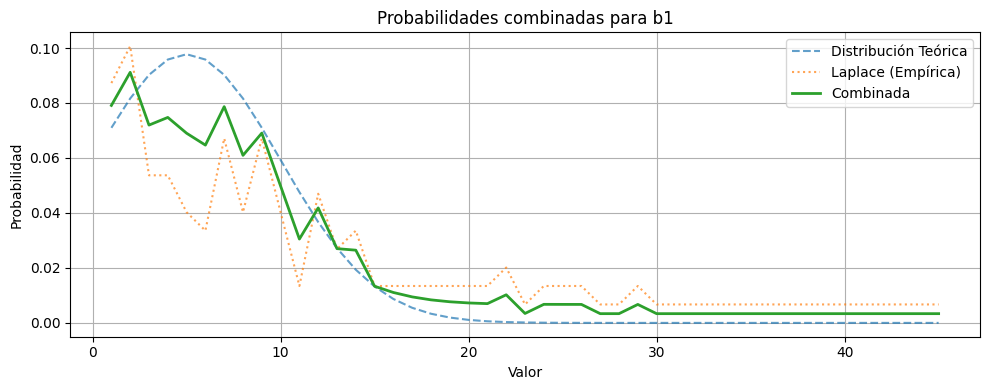

🎯 Siguientes valores más probables para b1:
  2: 0.0912
  1: 0.0791
  7: 0.0787
  4: 0.0747
  3: 0.0720
  9: 0.0690
  5: 0.0690
  6: 0.0647
  8: 0.0610
  10: 0.0498


In [77]:
b1_vals = next_gen_analyze("b1", body_size=104)

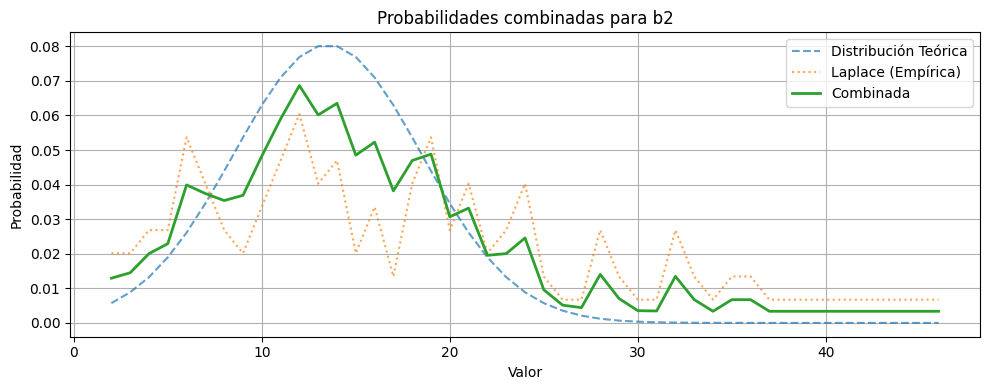

🎯 Siguientes valores más probables para b2:
  12: 0.0687
  14: 0.0635
  13: 0.0602
  11: 0.0590
  16: 0.0523
  19: 0.0488
  15: 0.0485
  10: 0.0483
  18: 0.0470
  6: 0.0399


In [78]:
b2_vals = next_gen_analyze("b2", body_size=104)

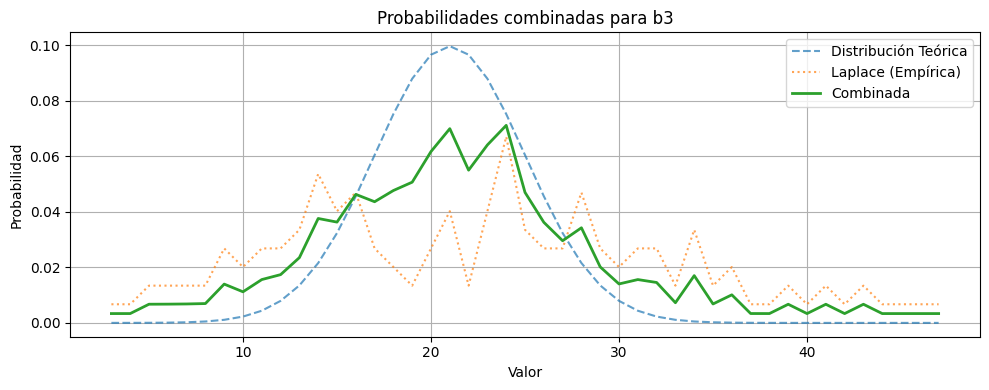

🎯 Siguientes valores más probables para b3:
  24: 0.0712
  21: 0.0700
  23: 0.0641
  20: 0.0618
  22: 0.0550
  19: 0.0507
  18: 0.0477
  25: 0.0470
  16: 0.0463
  17: 0.0437


In [79]:
b3_vals = next_gen_analyze("b3", body_size=104)

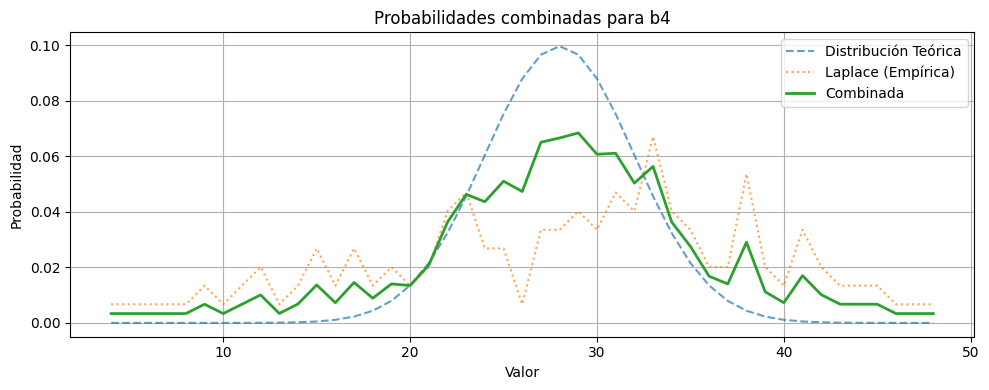

🎯 Siguientes valores más probables para b4:
  29: 0.0685
  28: 0.0666
  27: 0.0651
  31: 0.0611
  30: 0.0608
  33: 0.0564
  25: 0.0511
  32: 0.0504
  26: 0.0474
  23: 0.0463


In [80]:
b4_vals = next_gen_analyze("b4", body_size=104)

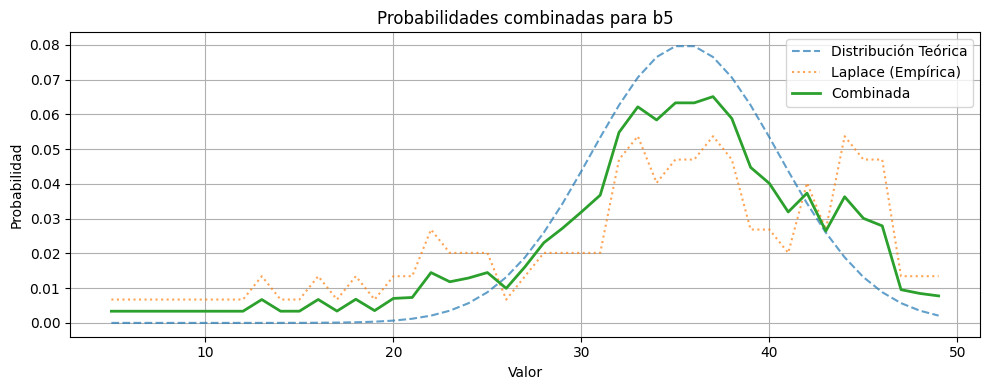

🎯 Siguientes valores más probables para b5:
  37: 0.0651
  35: 0.0633
  36: 0.0633
  33: 0.0621
  38: 0.0588
  34: 0.0584
  32: 0.0548
  39: 0.0447
  40: 0.0401
  42: 0.0373


In [81]:
b5_vals = next_gen_analyze("b5", body_size=104)

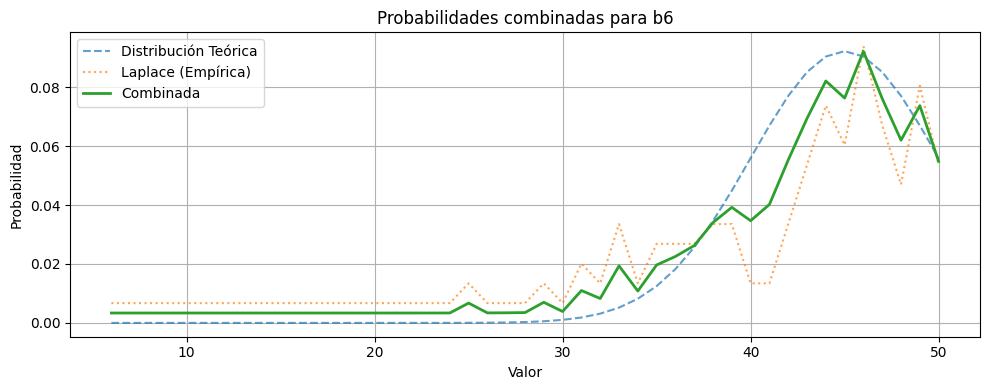

🎯 Siguientes valores más probables para b6:
  46: 0.0922
  44: 0.0821
  45: 0.0763
  47: 0.0761
  49: 0.0738
  43: 0.0694
  48: 0.0620
  42: 0.0553
  50: 0.0548
  41: 0.0402


In [82]:
b6_vals = next_gen_analyze("b6", body_size=104)